### Forecasting IMMP by XGBoost Model

This project aim to forecast the IMMP price utilising XGBoost model. Additionally, indicators such as EMA 10, 20, 50, 200, and MACD have been used as exogenous data.


### Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

#### Load Data

In [72]:
df = yf.download('IMMP', period='max',interval='1d', multi_level_index=False,)
df= df.reset_index()
df

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2012-04-19,23.333332,25.500000,23.333332,25.000000,1110
1,2012-04-20,24.000000,25.500000,23.666668,23.666668,1290
2,2012-04-23,21.333332,23.000000,21.333332,23.000000,1530
3,2012-04-24,21.333332,21.666668,21.333332,21.666668,570
4,2012-04-25,22.566668,22.666668,21.333332,22.600000,540
...,...,...,...,...,...,...
3511,2026-04-08,0.350000,0.370000,0.350000,0.370000,794500
3512,2026-04-09,0.320000,0.340000,0.320000,0.340000,1016400
3513,2026-04-10,0.310000,0.330000,0.300000,0.320000,895200
3514,2026-04-13,0.310000,0.320000,0.290000,0.320000,867100


In [74]:
df.set_index("Date", inplace=True)
df = df.sort_index()

In [75]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2012-04-19,23.333332,25.500000,23.333332,25.000000,1110
2012-04-20,24.000000,25.500000,23.666668,23.666668,1290
2012-04-23,21.333332,23.000000,21.333332,23.000000,1530
2012-04-24,21.333332,21.666668,21.333332,21.666668,570
2012-04-25,22.566668,22.666668,21.333332,22.600000,540


### Indicators

In [76]:
# Indicators
df['ema10'] = df.Close.ewm(min_periods=10, span=10).mean()
df['ema12'] = df.Close.ewm(min_periods=12, span=12).mean()
df['ema20'] = df.Close.ewm(min_periods=20, span=20).mean()
df['ema26'] = df.Close.ewm(min_periods=26, span=26).mean()
df['ema50'] = df.Close.ewm(min_periods=50, span=50).mean()
df['ema200'] = df.Close.ewm(min_periods=200, span=200).mean()
df['MACD'] = df['ema26'] - df['ema12']
df['MACD_signal']=df.MACD.ewm(min_periods=9, span=9).mean()

In [77]:
df=df.dropna()

In [78]:
train, test = df[:-60], df[-60:]

In [79]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

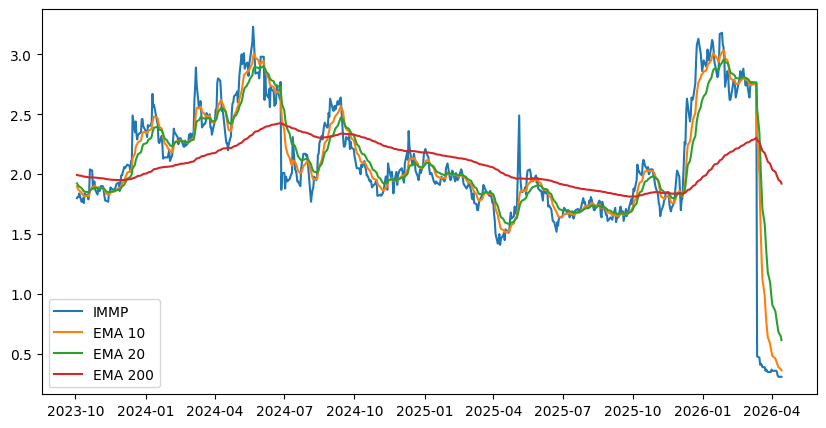

In [102]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test['Close'], label= 'IMMP')
plt.plot(test.index, test['ema10'], label= 'EMA 10')
plt.plot(test.index, test['ema20'], label= 'EMA 20')
plt.plot(test.index, test['ema200'], label= 'EMA 200')
plt.legend()
plt.show()

### Feature Engineering

In [81]:
# target feature
target='Close'

In [82]:
# exogenous variables
exogenous=['ema10','ema20','ema12','ema26','ema50','ema200','MACD','MACD_signal']

In [83]:
# function to make lag features

def make_features(data):
    for lag in range(1,31):
        data[f'{target}_lag{lag}'] = data[target].shift(lag)
    #exogenous lags
    for col in exogenous:
        for lag in range(1,31):
            data[f'{col}_lag{lag}']=data[col].shift(lag)
    return data

In [84]:
train=make_features(train).dropna()
test=make_features(test).dropna()

In [85]:
# function to add features
features= [c for c in train.columns if c != target]

In [86]:
#creating x_train, y_train,x_test,y_test
X_train, y_train = train[features],train[target]
X_test, y_test = test[features], test[target]

### XGBoost Model

In [87]:
#model
model = XGBRegressor()

In [88]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Predict

In [89]:
pred = model.predict(X_test)

### Accuracy Predicted vs Actual

In [90]:
# Compute accuracy metrics
rmse = np.sqrt(mean_squared_error(test['Close'], pred))
mae = mean_absolute_error(test['Close'], pred)
r2 = r2_score(test['Close'], pred)
mape = mean_absolute_percentage_error(test['Close'], pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:4f}")

RMSE: 0.0888
MAE: 0.0445
R² Score: 0.9704
MAPE: 0.052089


### Checking for overfitting

In [91]:
#Overffitig check
p_train = model.predict(X_train)
p_test = model.predict(X_test)
r2_train = r2_score(train['Close'],p_train)
r2_test = r2_score(test['Close'],p_test)

print(f"Train R2: {r2_train}")
print(f"Test R2: {r2_test}")

Train R2: 0.9999545722414178
Test R2: 0.9703960815552783


### Predicted vs Actual Plot

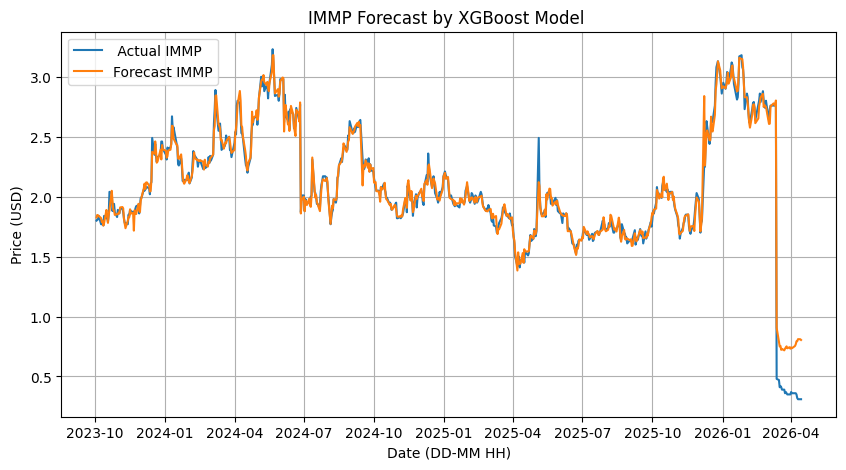

In [103]:
plt.figure(figsize= (10,5))
plt.plot(test.index, test['Close'], label=' Actual IMMP')
plt.plot(test.index, pred, label = 'Forecast IMMP')
plt.title('IMMP Forecast by XGBoost Model ')
plt.xlabel('Date (DD-MM HH)')
plt.ylabel('Price (USD)')
plt.grid()
plt.legend()
plt.show()

### Feature importance

<Axes: >

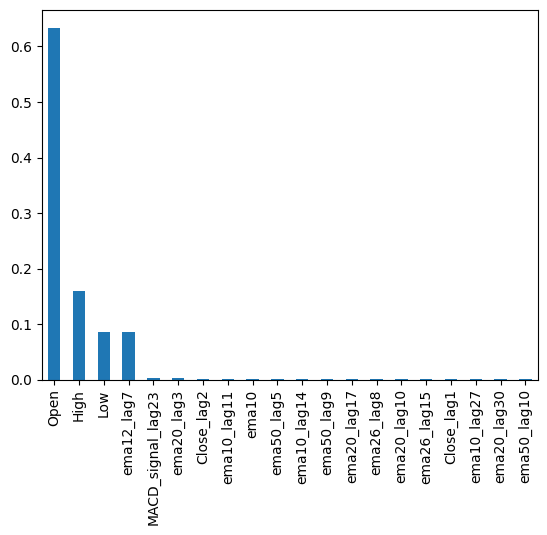

In [93]:
#feature importcance
importance= model.feature_importances_
f_imp =pd.Series(importance, index= X_train.columns).sort_values(ascending=False)
f_imp.head(20).plot(kind='bar')

### Residuals

Text(0.5, 1.0, 'Distribution of residuals')

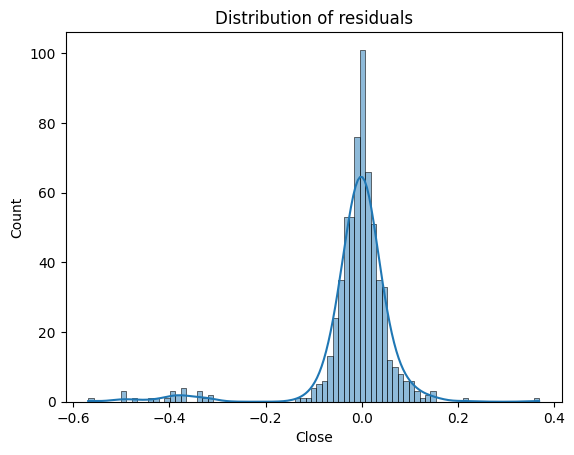

In [94]:
#residuals
residuals= y_test - pred
sns.histplot(residuals, kde=True)
plt.title('Distribution of residuals')

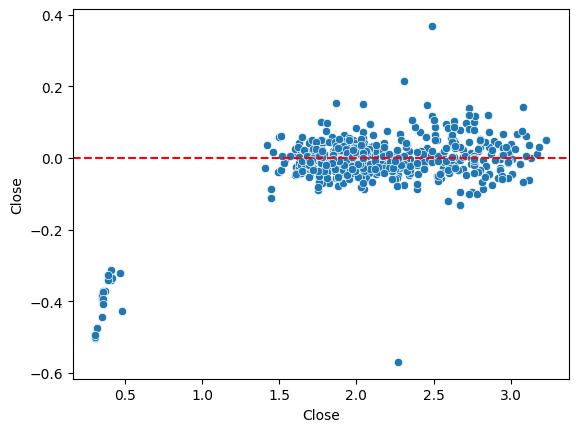

In [95]:
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0,color='red', linestyle='--')
plt.show()

### Forecast 1 Day ahead

In [96]:
X_test.tail(1)

,High,Low,Open,Volume,ema10,ema12,ema20,ema26,ema50,ema200,...,MACD_signal_lag21,MACD_signal_lag22,MACD_signal_lag23,MACD_signal_lag24,MACD_signal_lag25,MACD_signal_lag26,MACD_signal_lag27,MACD_signal_lag28,MACD_signal_lag29,MACD_signal_lag30
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-14,0.32,0.3,0.31,542500,0.363281,0.399278,0.615817,0.797603,1.342374,1.921533,...,0.052835,0.017362,0.018149,0.018744,0.019053,0.018945,0.018251,0.01675,0.014152,0.010847


In [98]:
last_row = X_test.iloc[-1:].copy()
new_time = X_test.index[-1] + pd.Timedelta(days=1)
last_row.index=[new_time]
last_row

,High,Low,Open,Volume,ema10,ema12,ema20,ema26,ema50,ema200,...,MACD_signal_lag21,MACD_signal_lag22,MACD_signal_lag23,MACD_signal_lag24,MACD_signal_lag25,MACD_signal_lag26,MACD_signal_lag27,MACD_signal_lag28,MACD_signal_lag29,MACD_signal_lag30
2026-04-15,0.32,0.3,0.31,542500,0.363281,0.399278,0.615817,0.797603,1.342374,1.921533,...,0.052835,0.017362,0.018149,0.018744,0.019053,0.018945,0.018251,0.01675,0.014152,0.010847


In [99]:
predicted=model.predict(last_row)

##### Prediction

In [100]:
print(f"{last_row.index[0]} Prediction: {predicted[0]}")

2026-04-15 00:00:00 Prediction: 0.8044072985649109


### Prediction Plot

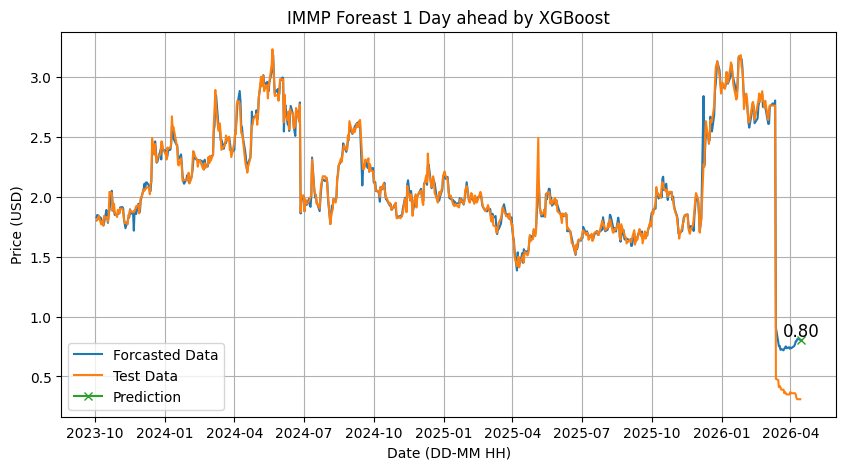

In [105]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
plt.plot(test.index, pred, label='Forcasted Data')
plt.plot(test.index, test['Close'], label='Test Data')
plt.plot(last_row.index, predicted, label='Prediction', marker='x',)
plt.text(last_row.index, predicted, f"{predicted[0]:.2f}",color='black', fontsize=12,ha='center', va='bottom')
plt.title('IMMP Foreast 1 Day ahead by XGBoost')
plt.xlabel('Date (DD-MM HH)')
plt.ylabel('Price (USD)')
plt.grid()
plt.legend()
plt.show()